# EIP-7623 Calldata Event Study

This notebook is a first-pass event study for the historical EIP-7623 calldata
floor. The goal is **not** to estimate the full future EIP-7999 data-resource
elasticity. EIP-7623 only gives a historical price shock for calldata-heavy
transactions, so the output should be read as a calldata-vs-execution
substitution prior.

The notebook is Xatu-first:

1. Use Xatu block timestamps to define the pre/post window.
2. Use Xatu transaction calldata byte counts and receipt gas to classify
   calldata-heavy transactions.
3. Aggregate daily and weekly.
4. Compute a descriptive logit-share response around the fork.

RPC is only needed if Xatu transaction/receipt coverage is not good enough for
this window.

## Why This Event Helps

EIP-7623 changed the transaction gas formula for calldata-heavy transactions to:

```text
tx.gasUsed = 21_000 + max(
    4 * tokens_in_calldata + execution_gas_used + create_cost,
    10 * tokens_in_calldata,
)
```

where:

```text
tokens_in_calldata = zero_calldata_bytes + 4 * nonzero_calldata_bytes
```

For floor-bound transactions this is an effective calldata price move from
`4/16` gas per zero/nonzero byte to `10/40`, i.e. a `2.5x` shock. EVM-heavy
transactions mostly stay on the standard branch.

So the clean question is:

> after calldata-heavy transactions became more expensive, did the calldata-heavy
> share of the data/execution bundle fall?

This identifies a calldata-specific response only. BAL bytes, access-list bytes,
authorization tuples, and blob hashes still need sensitivity analysis or later
historical calibration.

In [1]:
import os
from pathlib import Path
import sys

import clickhouse_connect
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

pd.options.display.float_format = "{:,.4f}".format

load_dotenv(PROJECT_ROOT / ".env")
missing = [name for name in ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"] if not os.environ.get(name)]
if missing:
    raise RuntimeError("Missing .env values: " + ", ".join(missing))

CLICKHOUSE_RAW_HOST = os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io")
raw_client = clickhouse_connect.get_client(
    host=CLICKHOUSE_RAW_HOST,
    port=int(os.environ.get("CLICKHOUSE_PORT", "443")),
    secure=True,
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
)

print("raw", CLICKHOUSE_RAW_HOST, raw_client.query("SELECT version()").result_rows)

raw clickhouse-raw.xatu.ethpandaops.io [('26.2.5.45',)]


## Parameters

The fork timestamp is a notebook parameter. The default below is the Pectra
mainnet activation date used for the first pass. If you want a slot/block-exact
cutoff, update `ACTIVATION_TS` and rerun; all classification is timestamp-based.

The default event window is intentionally moderate. It is large enough to see
pre/post daily movement but small enough that the first Xatu query should stay
cheap. Later we can expand or add robustness windows.

In [2]:
NETWORK = "mainnet"
START_DATE = "2025-03-07"
END_DATE = "2025-07-08"  # exclusive; includes 2025-07-07
ACTIVATION_TS = "2025-05-07 10:05:11"  # Pectra / EIP-7623 activation; adjust if needed

PRICE_RATIO_FLOOR_BOUND_7623 = 2.5
EXCLUDE_DAYS_AROUND_FORK = 1
PRE_WINDOW_DAYS = 60
POST_WINDOW_DAYS = 60

REFRESH = False
WRITE_CSV = True

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

TAG = f"{START_DATE}_{END_DATE}"
DAILY_CSV = DATA_DIR / f"eip7623_event_daily_{TAG}.csv"
WEEKLY_CSV = DATA_DIR / f"eip7623_event_weekly_{TAG}.csv"
SUMMARY_CSV = DATA_DIR / f"eip7623_event_summary_{TAG}.csv"
ROBUSTNESS_CSV = DATA_DIR / f"eip7623_event_robustness_{TAG}.csv"
AGGREGATION_CSV = DATA_DIR / f"eip7623_event_aggregation_sensitivity_{TAG}.csv"
STABLE_COHORT_THRESHOLD_CSV = DATA_DIR / f"eip7623_event_stable_cohort_threshold_{TAG}.csv"
STABLE_COHORT_DAILY_CSV = DATA_DIR / f"eip7623_event_stable_cohort_daily_{TAG}.csv"
STABLE_COHORT_SUMMARY_CSV = DATA_DIR / f"eip7623_event_stable_cohort_summary_{TAG}.csv"
STATE_CLEANED_DAILY_CSV = DATA_DIR / f"eip7623_event_state_cleaned_daily_{TAG}.csv"
STATE_CLEANED_SUMMARY_CSV = DATA_DIR / f"eip7623_event_state_cleaned_summary_{TAG}.csv"
ALPHA_SHARE_CSV = DATA_DIR / f"eip7623_event_alpha_data_given_rest_{TAG}.csv"
ELASTICITY_SWEEP_CSV = DATA_DIR / f"eip7623_event_implied_elasticity_sweep_{TAG}.csv"
PLACEBO_CSV = DATA_DIR / f"eip7623_event_placebos_{TAG}.csv"
COVERAGE_CSV = DATA_DIR / f"eip7623_event_xatu_coverage_{TAG}.csv"
GAS_COVERAGE_CSV = DATA_DIR / f"eip7623_event_receipt_gas_coverage_{TAG}.csv"

SHARE_PLOT = PLOTS_DIR / f"eip7623_event_data_share_{TAG}.png"
TREATED_PLOT = PLOTS_DIR / f"eip7623_event_treated_activity_{TAG}.png"

START_TS = f"{START_DATE} 00:00:00"
END_TS = f"{END_DATE} 00:00:00"
ACTIVATION_DATE = pd.Timestamp(ACTIVATION_TS).normalize()
START_TS, END_TS, ACTIVATION_TS

('2025-03-07 00:00:00', '2025-07-08 00:00:00', '2025-05-07 10:05:11')

## Utility Helpers

In [3]:
def load_or_query_csv(path: Path, query_fn, *, refresh: bool = REFRESH) -> pd.DataFrame:
    if path.exists() and not refresh:
        print("loaded", path)
        return pd.read_csv(path)
    df = query_fn()
    if WRITE_CSV:
        df.to_csv(path, index=False)
        print("wrote", path)
    return df


def logit(x: float) -> float:
    x = float(np.clip(x, 1e-12, 1 - 1e-12))
    return float(np.log(x / (1 - x)))


def millions(x, pos=None):
    return f"{x / 1_000_000:.0f}M"

## Xatu Capability Check

For this study we need transaction calldata bytes and receipt `gas_used`.
`execution_transaction` is useful for full transaction membership and calldata
fields; `canonical_execution_transaction` is useful because it includes receipt
gas. The coverage check below compares the two tables over the event window.

If receipt coverage is materially below raw transaction coverage, the event
study should switch to an RPC receipt pull for the missing transactions or a
sampled RPC validation before treating the estimate as final.

In [4]:
block_range = raw_client.query_df(
    """
    SELECT
        count() AS blocks,
        min(block_number) AS min_block,
        max(block_number) AS max_block,
        min(block_date_time) AS min_time,
        max(block_date_time) AS max_time
    FROM default.canonical_execution_block FINAL
    WHERE meta_network_name = {network:String}
      AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
      AND block_date_time < parseDateTime64BestEffort({end_ts:String})
    """,
    parameters={"network": NETWORK, "start_ts": START_TS, "end_ts": END_TS},
)
MIN_BLOCK = int(block_range.loc[0, "min_block"])
MAX_BLOCK = int(block_range.loc[0, "max_block"])
N_BLOCKS = int(block_range.loc[0, "blocks"])
block_range

,blocks,min_block,max_block,min_time,max_time
0,879467,21991287,22870753,2025-03-07 00:00:11,2025-07-07 23:59:59


In [5]:
schema_checks = {}
for table in ["execution_transaction", "canonical_execution_transaction", "canonical_execution_block"]:
    desc = raw_client.query_df(f"DESCRIBE TABLE default.{table}")
    cols = desc[desc["name"].str.contains("input|gas|time|hash|type|block", case=False, regex=True)]
    schema_checks[table] = cols[["name", "type"]]
    print("\n", table)
    display(schema_checks[table])


 execution_transaction


,name,type
0,updated_date_time,DateTime
1,block_number,UInt64
2,block_hash,FixedString(66)
3,parent_hash,FixedString(66)
5,hash,FixedString(66)
9,gas_price,UInt128
10,gas,UInt64
11,gas_tip_cap,Nullable(UInt128)
12,gas_fee_cap,Nullable(UInt128)
14,type,UInt8



 canonical_execution_transaction


,name,type
0,updated_date_time,DateTime
1,block_number,UInt64
3,transaction_hash,FixedString(66)
8,input,Nullable(String)
9,gas_limit,UInt64
10,gas_used,UInt64
11,gas_price,UInt128
12,transaction_type,UInt8
13,max_priority_fee_per_gas,UInt64
14,max_fee_per_gas,UInt64



 canonical_execution_block


,name,type
0,updated_date_time,DateTime
1,block_date_time,DateTime64(3)
2,block_number,UInt64
3,block_hash,FixedString(66)
5,gas_used,Nullable(UInt64)
6,gas_limit,UInt64
9,base_fee_per_gas,Nullable(UInt64)


In [6]:
def query_coverage():
    return raw_client.query_df(
        """
        WITH blocks AS
        (
            SELECT block_number, toDate(block_date_time) AS date
            FROM default.canonical_execution_block FINAL
            WHERE meta_network_name = {network:String}
              AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
              AND block_date_time < parseDateTime64BestEffort({end_ts:String})
        ),
        raw_counts AS
        (
            SELECT block_number, count() AS raw_tx_count
            FROM default.execution_transaction FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
            GROUP BY block_number
        ),
        receipt_counts AS
        (
            SELECT block_number, count() AS receipt_tx_count
            FROM default.canonical_execution_transaction FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
            GROUP BY block_number
        )
        SELECT
            b.date AS date,
            count() AS block_count,
            sum(ifNull(r.raw_tx_count, 0)) AS raw_tx_count,
            sum(ifNull(c.receipt_tx_count, 0)) AS receipt_tx_count,
            countIf(ifNull(r.raw_tx_count, 0) != ifNull(c.receipt_tx_count, 0)) AS blocks_with_tx_count_mismatch,
            sum(abs(toInt64(ifNull(r.raw_tx_count, 0)) - toInt64(ifNull(c.receipt_tx_count, 0)))) AS tx_count_abs_delta
        FROM blocks AS b
        LEFT JOIN raw_counts AS r USING block_number
        LEFT JOIN receipt_counts AS c USING block_number
        GROUP BY b.date
        ORDER BY b.date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "end_ts": END_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
        },
        settings={"max_execution_time": 300},
    )

coverage = load_or_query_csv(COVERAGE_CSV, query_coverage)
coverage["date"] = pd.to_datetime(coverage["date"])
coverage["receipt_coverage_ratio"] = coverage["receipt_tx_count"] / coverage["raw_tx_count"].replace(0, np.nan)
coverage_summary = pd.DataFrame(
    [
        {
            "days": len(coverage),
            "raw_tx_count": int(coverage["raw_tx_count"].sum()),
            "receipt_tx_count": int(coverage["receipt_tx_count"].sum()),
            "overall_receipt_coverage_ratio": float(coverage["receipt_tx_count"].sum() / coverage["raw_tx_count"].sum()),
            "days_with_mismatch": int((coverage["tx_count_abs_delta"] > 0).sum()),
            "tx_count_abs_delta": int(coverage["tx_count_abs_delta"].sum()),
        }
    ]
)
coverage_summary

loaded /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_xatu_coverage_2025-03-07_2025-07-08.csv


,days,raw_tx_count,receipt_tx_count,overall_receipt_coverage_ratio,days_with_mismatch,tx_count_abs_delta
0,123,107812531,160157472,1.4855,44,52344941


## Receipt Gas Coverage Check

The raw `execution_transaction` comparison can be misleading if that table is patchy for part of the historical window. The stronger Xatu sufficiency check is whether summing `canonical_execution_transaction.gas_used` reproduces `canonical_execution_block.gas_used`. If this matches, the canonical transaction table has the receipt-gas coverage needed for the EIP-7623 event metrics.

In [7]:
def query_receipt_gas_coverage():
    return raw_client.query_df(
        """
        WITH blocks AS
        (
            SELECT
                block_number,
                toDate(block_date_time) AS date,
                gas_used AS block_gas_used_raw
            FROM default.canonical_execution_block FINAL
            WHERE meta_network_name = {network:String}
              AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
              AND block_date_time < parseDateTime64BestEffort({end_ts:String})
        ),
        tx AS
        (
            SELECT
                block_number,
                sum(gas_used) AS tx_receipt_gas_used_raw,
                count() AS tx_count_raw
            FROM default.canonical_execution_transaction FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
            GROUP BY block_number
        )
        SELECT
            date,
            count() AS block_count,
            sum(block_gas_used_raw) AS block_gas_used,
            sum(ifNull(tx_receipt_gas_used_raw, 0)) AS tx_receipt_gas_used,
            sum(block_gas_used_raw) - sum(ifNull(tx_receipt_gas_used_raw, 0)) AS gas_delta,
            countIf(block_gas_used_raw != ifNull(tx_receipt_gas_used_raw, 0)) AS mismatched_blocks
        FROM blocks
        LEFT JOIN tx USING block_number
        GROUP BY date
        ORDER BY date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "end_ts": END_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
        },
        settings={"max_execution_time": 300},
    )


gas_coverage = load_or_query_csv(GAS_COVERAGE_CSV, query_receipt_gas_coverage)
gas_coverage["date"] = pd.to_datetime(gas_coverage["date"])
gas_coverage["receipt_gas_coverage_ratio"] = gas_coverage["tx_receipt_gas_used"] / gas_coverage["block_gas_used"].replace(0, np.nan)
gas_coverage_summary = pd.DataFrame(
    [
        {
            "days": len(gas_coverage),
            "block_gas_used": int(gas_coverage["block_gas_used"].sum()),
            "tx_receipt_gas_used": int(gas_coverage["tx_receipt_gas_used"].sum()),
            "overall_receipt_gas_coverage_ratio": float(gas_coverage["tx_receipt_gas_used"].sum() / gas_coverage["block_gas_used"].sum()),
            "days_with_gas_mismatch": int((gas_coverage["gas_delta"] != 0).sum()),
            "mismatched_blocks": int(gas_coverage["mismatched_blocks"].sum()),
            "gas_delta": int(gas_coverage["gas_delta"].sum()),
        }
    ]
)
gas_coverage_summary

loaded /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_receipt_gas_coverage_2025-03-07_2025-07-08.csv


,days,block_gas_used,tx_receipt_gas_used,overall_receipt_gas_coverage_ratio,days_with_gas_mismatch,mismatched_blocks,gas_delta
0,123,16025479678092,16025479678092,1.0000,0,0,0


## Daily EIP-7623 Event Metrics

The transaction-level proxy uses receipt gas as the observed transaction body:

```text
receipt_body_gas = receipt_gas_used - 21_000
```

For pre-fork transactions, `would_bind_7623_proxy` means the EIP-7623 floor
would have exceeded the observed body gas.

For post-fork transactions, `observed_7623_floor_bound_proxy` means the receipt
body is at or below the floor. This means the main treated group is the
**surviving floor-bound group**: transactions that remain floor-bound after the
price shock. That is useful descriptively, but composition can change after the
fork, so it should not be called the full calldata demand elasticity.

The share metric is deliberately simple:

```text
data_share_rest_gas_proxy =
    treated_standard_calldata_gas /
    (treated_standard_calldata_gas + control_execution_body_gas_proxy)
```

where `treated_standard_calldata_gas = 4 * calldata_tokens` for the treated
calldata-heavy group. This keeps the numerator in gas units before applying the
floor shock.

The notebook reports two price-ratio versions:

```text
theoretical ratio = 2.5

effective ratio =
    pre-fork treated_floor_7623_gas /
    pre-fork treated_receipt_body_gas
```

The theoretical ratio is the clean byte-price shock. The effective ratio is the
more realistic transaction-level shock because base gas and non-calldata body gas
make the all-in transaction price move smaller than `2.5x`.


In [8]:
def query_daily_event_metrics():
    return raw_client.query_df(
        """
        WITH tx AS
        (
            SELECT
                block_number,
                transaction_hash,
                toUInt64(n_input_bytes) AS calldata_bytes_raw,
                toUInt64(n_input_zero_bytes) AS calldata_zero_bytes_raw,
                toUInt64(n_input_nonzero_bytes) AS calldata_nonzero_bytes_raw,
                toInt64(n_input_zero_bytes + 4 * n_input_nonzero_bytes) AS calldata_tokens_raw,
                toInt64(4 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes)) AS standard_calldata_gas_raw,
                toInt64(10 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes)) AS floor_7623_gas_raw,
                toInt64(gas_used) AS receipt_gas_used_raw,
                greatest(toInt64(gas_used) - 21000, 0) AS receipt_body_gas_raw,
                greatest(greatest(toInt64(gas_used) - 21000, 0) - toInt64(4 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes)), 0) AS execution_body_gas_proxy_raw
            FROM default.canonical_execution_transaction FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
        ),
        joined AS
        (
            SELECT
                toDate(b.block_date_time) AS date,
                b.block_date_time AS block_time,
                b.block_number AS block_number,
                b.base_fee_per_gas AS base_fee_per_gas,
                t.*,
                (t.floor_7623_gas_raw > t.receipt_body_gas_raw AND t.calldata_tokens_raw > 0) AS would_bind_7623_proxy,
                (t.floor_7623_gas_raw >= t.receipt_body_gas_raw AND t.calldata_tokens_raw > 0) AS observed_7623_floor_bound_proxy,
                if(
                    b.block_date_time < parseDateTime64BestEffort({activation_ts:String}),
                    (t.floor_7623_gas_raw > t.receipt_body_gas_raw AND t.calldata_tokens_raw > 0),
                    (t.floor_7623_gas_raw >= t.receipt_body_gas_raw AND t.calldata_tokens_raw > 0)
                ) AS treated_proxy
            FROM tx AS t
            INNER JOIN default.canonical_execution_block AS b FINAL USING block_number
            WHERE b.meta_network_name = {network:String}
              AND b.block_date_time >= parseDateTime64BestEffort({start_ts:String})
              AND b.block_date_time < parseDateTime64BestEffort({end_ts:String})
        )
        SELECT
            date,
            min(block_time) AS first_block_time,
            max(block_time) AS last_block_time,
            uniqExact(block_number) AS block_count,
            count() AS tx_count,
            countIf(calldata_bytes_raw > 0) AS txs_with_calldata,
            countIf(treated_proxy) AS treated_tx_count,
            countIf(would_bind_7623_proxy) AS would_bind_7623_tx_count,
            countIf(observed_7623_floor_bound_proxy) AS observed_7623_floor_bound_tx_count,
            sum(calldata_bytes_raw) AS total_calldata_bytes,
            sum(calldata_zero_bytes_raw) AS total_calldata_zero_bytes,
            sum(calldata_nonzero_bytes_raw) AS total_calldata_nonzero_bytes,
            sum(calldata_tokens_raw) AS total_calldata_tokens,
            sum(standard_calldata_gas_raw) AS total_standard_calldata_gas,
            sum(floor_7623_gas_raw) AS total_floor_7623_gas,
            sum(receipt_gas_used_raw) AS total_receipt_gas_used,
            sum(receipt_body_gas_raw) AS total_receipt_body_gas,
            sum(execution_body_gas_proxy_raw) AS total_execution_body_gas_proxy,
            sumIf(calldata_bytes_raw, treated_proxy) AS treated_calldata_bytes,
            sumIf(calldata_tokens_raw, treated_proxy) AS treated_calldata_tokens,
            sumIf(standard_calldata_gas_raw, treated_proxy) AS treated_standard_calldata_gas,
            sumIf(floor_7623_gas_raw, treated_proxy) AS treated_floor_7623_gas,
            sumIf(receipt_body_gas_raw, treated_proxy) AS treated_receipt_body_gas,
            sumIf(execution_body_gas_proxy_raw, treated_proxy) AS treated_execution_body_gas_proxy,
            sumIf(execution_body_gas_proxy_raw, NOT treated_proxy) AS control_execution_body_gas_proxy,
            sumIf(calldata_bytes_raw, NOT treated_proxy) AS control_calldata_bytes,
            sumIf(standard_calldata_gas_raw, NOT treated_proxy) AS control_standard_calldata_gas,
            avg(toFloat64(base_fee_per_gas)) AS tx_weighted_mean_base_fee_per_gas
        FROM joined
        GROUP BY date
        ORDER BY date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "end_ts": END_TS,
            "activation_ts": ACTIVATION_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
        },
        settings={"max_execution_time": 600},
    )


REQUIRED_DAILY_COLUMNS = {
    "treated_receipt_body_gas",
    "treated_execution_body_gas_proxy",
}

daily = load_or_query_csv(DAILY_CSV, query_daily_event_metrics)
if not REQUIRED_DAILY_COLUMNS.issubset(daily.columns):
    print("cached daily CSV is missing new columns; refreshing", DAILY_CSV)
    daily = query_daily_event_metrics()
    if WRITE_CSV:
        daily.to_csv(DAILY_CSV, index=False)
        print("wrote", DAILY_CSV)

daily = daily.rename(
    columns={
        "total_calldata_bytes": "calldata_bytes",
        "total_calldata_zero_bytes": "calldata_zero_bytes",
        "total_calldata_nonzero_bytes": "calldata_nonzero_bytes",
        "total_calldata_tokens": "calldata_tokens",
        "total_standard_calldata_gas": "standard_calldata_gas",
        "total_floor_7623_gas": "floor_7623_gas",
        "total_receipt_gas_used": "receipt_gas_used",
        "total_receipt_body_gas": "receipt_body_gas",
        "total_execution_body_gas_proxy": "execution_body_gas_proxy",
    }
)
daily["date"] = pd.to_datetime(daily["date"])
for col in ["first_block_time", "last_block_time"]:
    daily[col] = pd.to_datetime(daily[col])

daily["phase"] = np.where(daily["last_block_time"] < pd.Timestamp(ACTIVATION_TS), "pre", "post")
daily.loc[daily["date"].dt.normalize() == ACTIVATION_DATE, "phase"] = "activation_day"

daily["treated_tx_share"] = daily["treated_tx_count"] / daily["tx_count"].replace(0, np.nan)
daily["treated_calldata_byte_share"] = daily["treated_calldata_bytes"] / daily["calldata_bytes"].replace(0, np.nan)
daily["data_share_rest_gas_proxy"] = daily["treated_standard_calldata_gas"] / (
    daily["treated_standard_calldata_gas"] + daily["control_execution_body_gas_proxy"]
).replace(0, np.nan)
daily["treated_calldata_bytes_per_block"] = daily["treated_calldata_bytes"] / daily["block_count"].replace(0, np.nan)
daily["calldata_bytes_per_block"] = daily["calldata_bytes"] / daily["block_count"].replace(0, np.nan)
daily["standard_calldata_gas_per_block"] = daily["standard_calldata_gas"] / daily["block_count"].replace(0, np.nan)

if WRITE_CSV:
    daily.to_csv(DAILY_CSV, index=False)
    print("wrote", DAILY_CSV)

daily.head()

loaded /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_daily_2025-03-07_2025-07-08.csv
wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_daily_2025-03-07_2025-07-08.csv


,date,first_block_time,last_block_time,block_count,tx_count,txs_with_calldata,treated_tx_count,would_bind_7623_tx_count,observed_7623_floor_bound_tx_count,calldata_bytes,...,treated_calldata_bytes_per_block,calldata_bytes_per_block,standard_calldata_gas_per_block,control_execution_body_gas_state_cleaned,data_share_rest_state_cleaned_gas_proxy,new_storage_slots,new_accounts_first_seen_proxy,new_contract_accounts,code_bytes,historical_state_creation_gas
0,2025-03-07,2025-03-07 00:00:11,2025-03-07 23:59:59,7147,1277137,858053,20164,20164,20164,497223560,...,"3,495.6131","69,570.9473","613,446.5695",74007939144,0.0040,901591,180779,67491,12459800,25043255000
1,2025-03-08,2025-03-08 00:00:11,2025-03-08 23:59:59,7147,1097056,708290,21586,21586,21586,463935462,...,"3,239.5514","64,913.3150","636,770.2180",65463438269,0.0045,1172337,246634,142184,39778377,37568265400
2,2025-03-09,2025-03-09 00:00:11,2025-03-09 23:59:59,7155,1123093,725940,18392,18392,18392,509333094,...,"2,991.3560","71,185.6176","632,103.9866",72426503983,0.0037,1106256,235940,126620,11467835,30317187000
3,2025-03-10,2025-03-10 00:00:11,2025-03-10 23:59:59,7157,1283100,864983,17467,17467,17467,615398937,...,"4,524.9627","85,985.5997","779,417.2111",77765285511,0.0053,731338,149131,39008,9357554,20226545800
4,2025-03-11,2025-03-11 00:00:11,2025-03-11 23:59:59,7152,1311724,891353,16664,16664,16664,579692748,...,"3,654.6988","81,053.2366","719,918.2483",78478424513,0.0040,666535,142816,23065,10257467,18952593400


## State-Cleaned Rest Denominator

The baseline event-study share compares calldata-heavy activity against
non-calldata receipt body gas. That body gas still includes historical
state-creation costs. If we want the data-vs-execution split inside Maria's
`rest` bucket, we should remove state creation first:

```text
execution_denominator_state_cleaned =
    non_calldata_body_gas - historical_state_creation_gas
```

This section estimates current-rule historical state-creation gas from Xatu:

```text
historical_state_creation_gas =
    20_000 * new_storage_slots
  + 25_000 * new_accounts_first_seen_proxy
  + 200 * code_bytes
```

This is the same accounting idea used in the Glamsterdam regular-gas notebook
before replacing those components with EIP-8037 state gas. EIP-7702 delegation
state costs are not included here because the Xatu-only event notebook does not
pull authorization lists; that should be tiny relative to storage/account/code in
this window, but it is still a caveat.

In [9]:
ZERO_WORD = "0x" + "00" * 32


def query_state_creation_current_rule_daily():
    return raw_client.query_df(
        """
        WITH
            blocks AS
            (
                SELECT block_number, toDate(block_date_time) AS date
                FROM default.canonical_execution_block FINAL
                WHERE meta_network_name = {network:String}
                  AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                  AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
                  AND block_date_time < parseDateTime64BestEffort({end_ts:String})
            ),
            storage_by_block AS
            (
                SELECT
                    block_number,
                    uniqExact(tuple(lower(address), lower(slot))) AS new_storage_slots
                FROM default.canonical_execution_storage_diffs FINAL
                WHERE meta_network_name = {network:String}
                  AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                  AND lower(from_value) = {zero_word:String}
                  AND lower(to_value) != {zero_word:String}
                GROUP BY block_number
            ),
            code_by_block AS
            (
                SELECT
                    block_number,
                    uniqExact(lower(contract_address)) AS new_contract_accounts,
                    sum(n_code_bytes) AS code_bytes
                FROM default.canonical_execution_contracts FINAL
                WHERE meta_network_name = {network:String}
                  AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                GROUP BY block_number
            ),
            candidates AS
            (
                SELECT address, min(candidate_block) AS candidate_block
                FROM
                (
                    SELECT lower(contract_address) AS address, min(block_number) AS candidate_block
                    FROM default.canonical_execution_contracts FINAL
                    WHERE meta_network_name = {network:String}
                      AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                    GROUP BY address
                    UNION ALL
                    SELECT lower(address) AS address, min(block_number) AS candidate_block
                    FROM default.canonical_execution_balance_diffs FINAL
                    WHERE meta_network_name = {network:String}
                      AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                      AND from_value = 0
                      AND to_value > 0
                    GROUP BY address
                    UNION ALL
                    SELECT lower(address) AS address, min(block_number) AS candidate_block
                    FROM default.canonical_execution_nonce_diffs FINAL
                    WHERE meta_network_name = {network:String}
                      AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                      AND from_value = 0
                      AND to_value > 0
                    GROUP BY address
                )
                GROUP BY address
            ),
            first_appearances AS
            (
                SELECT lower(address) AS address, min(block_number) AS first_block
                FROM default.canonical_execution_address_appearances FINAL
                WHERE meta_network_name = {network:String}
                  AND lower(address) GLOBAL IN (SELECT address FROM candidates)
                GROUP BY address
            ),
            new_accounts_by_block AS
            (
                SELECT c.candidate_block AS block_number, count() AS new_accounts_first_seen_proxy
                FROM candidates AS c
                INNER JOIN first_appearances AS f USING address
                WHERE f.first_block BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                GROUP BY c.candidate_block
            )
        SELECT
            b.date AS date,
            count() AS block_count,
            sum(ifNull(s.new_storage_slots, 0)) AS new_storage_slots,
            sum(ifNull(a.new_accounts_first_seen_proxy, 0)) AS new_accounts_first_seen_proxy,
            sum(ifNull(c.new_contract_accounts, 0)) AS new_contract_accounts,
            sum(ifNull(c.code_bytes, 0)) AS code_bytes
        FROM blocks AS b
        GLOBAL LEFT JOIN storage_by_block AS s USING block_number
        GLOBAL LEFT JOIN new_accounts_by_block AS a USING block_number
        GLOBAL LEFT JOIN code_by_block AS c USING block_number
        GROUP BY b.date
        ORDER BY b.date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "end_ts": END_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
            "zero_word": ZERO_WORD,
        },
        settings={"max_execution_time": 600},
    )

state_clean_daily = load_or_query_csv(STATE_CLEANED_DAILY_CSV, query_state_creation_current_rule_daily)
state_clean_daily["date"] = pd.to_datetime(state_clean_daily["date"])
state_clean_daily["historical_state_creation_gas"] = (
    20_000 * state_clean_daily["new_storage_slots"]
    + 25_000 * state_clean_daily["new_accounts_first_seen_proxy"]
    + 200 * state_clean_daily["code_bytes"]
)

state_cols = [
    "date",
    "new_storage_slots",
    "new_accounts_first_seen_proxy",
    "new_contract_accounts",
    "code_bytes",
    "historical_state_creation_gas",
]
daily = daily.drop(columns=[col for col in state_cols if col in daily.columns and col != "date"], errors="ignore")
daily = daily.merge(state_clean_daily[state_cols], on="date", how="left", validate="one_to_one")
for col in state_cols:
    if col != "date":
        daily[col] = daily[col].fillna(0)

daily["control_execution_body_gas_state_cleaned"] = (
    daily["control_execution_body_gas_proxy"]
    - daily["historical_state_creation_gas"]
).clip(lower=0)
daily["data_share_rest_state_cleaned_gas_proxy"] = daily["treated_standard_calldata_gas"] / (
    daily["treated_standard_calldata_gas"]
    + daily["control_execution_body_gas_state_cleaned"]
).replace(0, np.nan)

if WRITE_CSV:
    daily.to_csv(DAILY_CSV, index=False)
    state_clean_daily.to_csv(STATE_CLEANED_DAILY_CSV, index=False)
    print("wrote", DAILY_CSV)
    print("wrote", STATE_CLEANED_DAILY_CSV)

state_clean_daily.head()

loaded /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_state_cleaned_daily_2025-03-07_2025-07-08.csv
wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_daily_2025-03-07_2025-07-08.csv
wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_state_cleaned_daily_2025-03-07_2025-07-08.csv


,date,block_count,new_storage_slots,new_accounts_first_seen_proxy,new_contract_accounts,code_bytes,historical_state_creation_gas
0,2025-03-07,7152,901591,180779,67491,12459800,25043255000
1,2025-03-08,7152,1172337,246634,142184,39778377,37568265400
2,2025-03-09,7160,1106256,235940,126620,11467835,30317187000
3,2025-03-10,7157,731338,149131,39008,9357554,20226545800
4,2025-03-11,7157,666535,142816,23065,10257467,18952593400


### State-Cleaned Eta

This uses the same pre/post window and the same treated calldata numerator, but
replaces the execution-side denominator with the state-cleaned denominator. If
state creation is a small part of the control execution denominator, eta should
barely move. If state creation is large, the data share should rise and the eta
may change.

In [10]:
def weighted_data_share_state_cleaned(frame: pd.DataFrame) -> float:
    data = float(frame["treated_standard_calldata_gas"].sum())
    execution = float(frame["control_execution_body_gas_state_cleaned"].sum())
    return data / (data + execution) if (data + execution) > 0 else np.nan


def safe_eta_state_cleaned(pre_share: float, post_share: float, price_ratio: float) -> float:
    if not np.isfinite(pre_share) or not np.isfinite(post_share) or not np.isfinite(price_ratio) or price_ratio <= 1:
        return np.nan
    return -(logit(post_share) - logit(pre_share)) / np.log(price_ratio)


def effective_price_ratio_state_cleaned(frame: pd.DataFrame, denominator: str) -> float:
    numerator = float(frame["treated_floor_7623_gas"].sum())
    denom = float(frame[denominator].sum())
    return numerator / denom if denom > 0 else np.nan

# If this section runs before pre/post are defined during notebook edits, define
# the window locally with the same convention used below.
state_pre_start = ACTIVATION_DATE - pd.Timedelta(days=EXCLUDE_DAYS_AROUND_FORK + PRE_WINDOW_DAYS)
state_pre_end = ACTIVATION_DATE - pd.Timedelta(days=EXCLUDE_DAYS_AROUND_FORK)
state_post_start = ACTIVATION_DATE + pd.Timedelta(days=EXCLUDE_DAYS_AROUND_FORK + 1)
state_post_end = ACTIVATION_DATE + pd.Timedelta(days=EXCLUDE_DAYS_AROUND_FORK + POST_WINDOW_DAYS)

state_clean_pre = daily[(daily["date"] >= state_pre_start) & (daily["date"] < state_pre_end)].copy()
state_clean_post = daily[(daily["date"] >= state_post_start) & (daily["date"] <= state_post_end)].copy()

state_clean_pre_share = weighted_data_share_state_cleaned(state_clean_pre)
state_clean_post_share = weighted_data_share_state_cleaned(state_clean_post)
state_clean_effective_ratio = effective_price_ratio_state_cleaned(state_clean_pre, "treated_receipt_body_gas")

state_clean_summary = pd.DataFrame(
    [
        {
            "denominator": "control_noncalldata_body_minus_current_rule_state_creation",
            "pre_start": state_pre_start.date().isoformat(),
            "pre_end_exclusive": state_pre_end.date().isoformat(),
            "post_start": state_post_start.date().isoformat(),
            "post_end_inclusive": state_post_end.date().isoformat(),
            "pre_days": len(state_clean_pre),
            "post_days": len(state_clean_post),
            "pre_share_state_cleaned": state_clean_pre_share,
            "post_share_state_cleaned": state_clean_post_share,
            "effective_price_ratio_receipt_body_pre": state_clean_effective_ratio,
            "eta_theoretical_2p5_state_cleaned": safe_eta_state_cleaned(state_clean_pre_share, state_clean_post_share, PRICE_RATIO_FLOOR_BOUND_7623),
            "eta_effective_receipt_body_state_cleaned": safe_eta_state_cleaned(state_clean_pre_share, state_clean_post_share, state_clean_effective_ratio),
            "pre_historical_state_creation_gas_per_block": float(state_clean_pre["historical_state_creation_gas"].sum() / state_clean_pre["block_count"].sum()),
            "post_historical_state_creation_gas_per_block": float(state_clean_post["historical_state_creation_gas"].sum() / state_clean_post["block_count"].sum()),
            "pre_control_execution_gas_removed_share": float(state_clean_pre["historical_state_creation_gas"].sum() / state_clean_pre["control_execution_body_gas_proxy"].sum()),
            "post_control_execution_gas_removed_share": float(state_clean_post["historical_state_creation_gas"].sum() / state_clean_post["control_execution_body_gas_proxy"].sum()),
        }
    ]
)
if WRITE_CSV:
    state_clean_summary.to_csv(STATE_CLEANED_SUMMARY_CSV, index=False)
    print("wrote", STATE_CLEANED_SUMMARY_CSV)
state_clean_summary.T

wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_state_cleaned_summary_2025-03-07_2025-07-08.csv


,0
denominator,control_noncalldata_body_minus_current_rule_st...
pre_start,2025-03-07
pre_end_exclusive,2025-05-06
post_start,2025-05-09
post_end_inclusive,2025-07-07
pre_days,60
post_days,60
pre_share_state_cleaned,0.0065
post_share_state_cleaned,0.0047
effective_price_ratio_receipt_body_pre,2.1119


## Weekly Aggregation

Daily data are useful for inspection, but weekly aggregation is a cleaner first
view because rollup posting and transaction mix can be lumpy. The regression
stage later should treat daily/weekly as the main units, not individual blocks.

In [11]:
quantity_cols = [
    "block_count",
    "tx_count",
    "txs_with_calldata",
    "treated_tx_count",
    "would_bind_7623_tx_count",
    "observed_7623_floor_bound_tx_count",
    "calldata_bytes",
    "calldata_zero_bytes",
    "calldata_nonzero_bytes",
    "calldata_tokens",
    "standard_calldata_gas",
    "floor_7623_gas",
    "receipt_gas_used",
    "receipt_body_gas",
    "execution_body_gas_proxy",
    "treated_calldata_bytes",
    "treated_calldata_tokens",
    "treated_standard_calldata_gas",
    "treated_floor_7623_gas",
    "treated_receipt_body_gas",
    "treated_execution_body_gas_proxy",
    "control_execution_body_gas_proxy",
    "control_calldata_bytes",
    "control_standard_calldata_gas",
]
weekly = daily.set_index("date")[quantity_cols].resample("W-MON").sum().reset_index()
weekly["phase"] = np.where(weekly["date"] < ACTIVATION_DATE, "pre", "post")
weekly["treated_tx_share"] = weekly["treated_tx_count"] / weekly["tx_count"].replace(0, np.nan)
weekly["treated_calldata_byte_share"] = weekly["treated_calldata_bytes"] / weekly["calldata_bytes"].replace(0, np.nan)
weekly["data_share_rest_gas_proxy"] = weekly["treated_standard_calldata_gas"] / (
    weekly["treated_standard_calldata_gas"] + weekly["control_execution_body_gas_proxy"]
).replace(0, np.nan)
weekly["treated_calldata_bytes_per_block"] = weekly["treated_calldata_bytes"] / weekly["block_count"].replace(0, np.nan)
weekly["calldata_bytes_per_block"] = weekly["calldata_bytes"] / weekly["block_count"].replace(0, np.nan)

if WRITE_CSV:
    weekly.to_csv(WEEKLY_CSV, index=False)
    print("wrote", WEEKLY_CSV)

weekly.tail(10)

wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_weekly_2025-03-07_2025-07-08.csv


,date,block_count,tx_count,txs_with_calldata,treated_tx_count,would_bind_7623_tx_count,observed_7623_floor_bound_tx_count,calldata_bytes,calldata_zero_bytes,calldata_nonzero_bytes,...,treated_execution_body_gas_proxy,control_execution_body_gas_proxy,control_calldata_bytes,control_standard_calldata_gas,phase,treated_tx_share,treated_calldata_byte_share,data_share_rest_gas_proxy,treated_calldata_bytes_per_block,calldata_bytes_per_block
8,2025-05-05,49922,8787070,5679294,329338,329338,329338,2797479027,1726461120,1071017907,...,722980647,703254734662,2533185271,20229599788,pre,0.0375,0.0945,0.0054,"5,294.1340","56,036.9983"
9,2025-05-12,49616,9484872,6378283,114835,21866,114835,2846045528,1863877692,982167836,...,1065183204,680453193316,2739185605,22043308144,post,0.0121,0.0375,0.0017,"2,153.7392","57,361.4465"
10,2025-05-19,49784,9602734,6231406,103468,0,103468,2896558276,1857265491,1039292785,...,3391634172,676387847843,2724954320,21796657076,post,0.0108,0.0592,0.0033,"3,446.9700","58,182.5140"
11,2025-05-26,49944,9476392,6289874,142347,0,142347,2951960483,1897405429,1054555054,...,3181137552,682123022164,2791992356,22341744212,post,0.0150,0.0542,0.0031,"3,202.9498","59,105.4077"
12,2025-06-02,49964,9946881,6378556,162800,0,162800,3164920252,2058150532,1106769720,...,3008287416,671593813928,3010383041,23935392704,post,0.0164,0.0488,0.0030,"3,092.9712","63,344.0127"
13,2025-06-09,50001,9778568,6525705,146988,0,146988,3231000193,2115059355,1115940838,...,3662356854,674619703338,3045493577,23873719592,post,0.0150,0.0574,0.0036,"3,710.0581","64,618.7115"
14,2025-06-16,50029,9780814,6353649,129845,0,129845,3050951489,1961642812,1089308677,...,3227390670,677075017114,2885594535,23123916300,post,0.0133,0.0542,0.0032,"3,305.2221","60,983.6593"
15,2025-06-23,50024,9474438,6198088,120176,0,120176,3158394591,2007202369,1151192222,...,4768533570,680014571468,2923337314,23268862648,post,0.0127,0.0744,0.0047,"4,698.8901","63,137.5858"
16,2025-06-30,50066,10186436,6528938,153738,0,153738,3239757105,1966423789,1273333316,...,4598115144,663989356600,3012267671,25173618116,post,0.0151,0.0702,0.0046,"4,543.7909","64,709.7253"
17,2025-07-07,50038,9702588,6185036,183851,0,183851,3184806593,1996563502,1188243091,...,5456942520,674010632895,2915736157,23360181784,post,0.0189,0.0845,0.0054,"5,377.3220","63,647.7596"


## Descriptive Elasticity Prior

The first estimate is still intentionally descriptive:

```text
eta_data ~= -(logit(post_share) - logit(pre_share)) / log(price_ratio)
```

The notebook reports both:

- `eta_data_theoretical_2p5`, using the clean calldata-byte price shock `2.5x`.
- `eta_data_effective_receipt_body`, using the effective all-in transaction-body
  shock measured on the pre-fork treated group.

The second value is usually the better prior for simulator sweeps; the 2.5x
value is a clean upper-bound-style benchmark.


In [12]:
pre_start = ACTIVATION_DATE - pd.Timedelta(days=EXCLUDE_DAYS_AROUND_FORK + PRE_WINDOW_DAYS)
pre_end = ACTIVATION_DATE - pd.Timedelta(days=EXCLUDE_DAYS_AROUND_FORK)
post_start = ACTIVATION_DATE + pd.Timedelta(days=EXCLUDE_DAYS_AROUND_FORK + 1)
post_end = ACTIVATION_DATE + pd.Timedelta(days=EXCLUDE_DAYS_AROUND_FORK + POST_WINDOW_DAYS)


def weighted_data_share(frame: pd.DataFrame) -> float:
    data = float(frame["treated_standard_calldata_gas"].sum())
    execution = float(frame["control_execution_body_gas_proxy"].sum())
    return data / (data + execution) if (data + execution) > 0 else np.nan


def safe_eta(pre_share: float, post_share: float, price_ratio: float) -> float:
    if not np.isfinite(pre_share) or not np.isfinite(post_share) or not np.isfinite(price_ratio) or price_ratio <= 1:
        return np.nan
    return -(logit(post_share) - logit(pre_share)) / np.log(price_ratio)


def effective_price_ratio(frame: pd.DataFrame, denominator: str) -> float:
    numerator = float(frame["treated_floor_7623_gas"].sum())
    denom = float(frame[denominator].sum())
    return numerator / denom if denom > 0 else np.nan

pre = daily[(daily["date"] >= pre_start) & (daily["date"] < pre_end)].copy()
post = daily[(daily["date"] >= post_start) & (daily["date"] <= post_end)].copy()

pre_share = weighted_data_share(pre)
post_share = weighted_data_share(post)
effective_ratio_receipt_body = effective_price_ratio(pre, "treated_receipt_body_gas")
effective_ratio_standard_plus_exec = effective_price_ratio(
    pre.assign(
        treated_standard_plus_exec=(
            pre["treated_standard_calldata_gas"]
            + pre["treated_execution_body_gas_proxy"]
        )
    ),
    "treated_standard_plus_exec",
)

summary = pd.DataFrame(
    [
        {
            "pre_start": pre_start.date().isoformat(),
            "pre_end_exclusive": pre_end.date().isoformat(),
            "post_start": post_start.date().isoformat(),
            "post_end_inclusive": post_end.date().isoformat(),
            "pre_days": len(pre),
            "post_days": len(post),
            "theoretical_price_ratio": PRICE_RATIO_FLOOR_BOUND_7623,
            "effective_price_ratio_receipt_body_pre": effective_ratio_receipt_body,
            "effective_price_ratio_standard_plus_exec_pre": effective_ratio_standard_plus_exec,
            "pre_data_share_rest_gas_proxy": pre_share,
            "post_data_share_rest_gas_proxy": post_share,
            "logit_pre": logit(pre_share),
            "logit_post": logit(post_share),
            "eta_data_theoretical_2p5": safe_eta(pre_share, post_share, PRICE_RATIO_FLOOR_BOUND_7623),
            "eta_data_effective_receipt_body": safe_eta(pre_share, post_share, effective_ratio_receipt_body),
            "eta_data_effective_standard_plus_exec": safe_eta(pre_share, post_share, effective_ratio_standard_plus_exec),
            "pre_treated_calldata_bytes_per_block": float(pre["treated_calldata_bytes"].sum() / pre["block_count"].sum()),
            "post_treated_calldata_bytes_per_block": float(post["treated_calldata_bytes"].sum() / post["block_count"].sum()),
            "pre_treated_tx_share": float(pre["treated_tx_count"].sum() / pre["tx_count"].sum()),
            "post_treated_tx_share": float(post["treated_tx_count"].sum() / post["tx_count"].sum()),
            "xatu_raw_vs_canonical_tx_count_ratio": float(coverage["receipt_tx_count"].sum() / coverage["raw_tx_count"].replace(0, np.nan).sum()),
            "xatu_receipt_gas_coverage_ratio": float(gas_coverage["tx_receipt_gas_used"].sum() / gas_coverage["block_gas_used"].sum()),
        }
    ]
)
if WRITE_CSV:
    summary.to_csv(SUMMARY_CSV, index=False)
    print("wrote", SUMMARY_CSV)
summary.T

wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_summary_2025-03-07_2025-07-08.csv


,0
pre_start,2025-03-07
pre_end_exclusive,2025-05-06
post_start,2025-05-09
post_end_inclusive,2025-07-07
pre_days,60
post_days,60
theoretical_price_ratio,2.5000
effective_price_ratio_receipt_body_pre,2.1119
effective_price_ratio_standard_plus_exec_pre,2.1119
pre_data_share_rest_gas_proxy,0.0047


## Daily And Weekly Aggregation Sensitivity

The main headline above is a **pooled daily-window** estimate: sum all daily
pre-window quantities, compute one pre share; sum all post-window quantities,
compute one post share.

This table checks how much the answer changes if we instead average daily or
weekly share observations:

- `pooled_quantities`: denominator-weighted by construction; best for total
  activity accounting.
- `unweighted_mean_shares`: each day/week gets equal weight; sensitive to small
  quiet days.
- `block_weighted_mean_shares`: each day/week is weighted by its block count;
  close to unweighted here because every day has about the same number of
  blocks.

The effective price ratio is still measured from the pooled pre-fork treated
transactions so only the share aggregation changes.

In [13]:
def add_share_columns(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["data_share_rest_gas_proxy"] = out["treated_standard_calldata_gas"] / (
        out["treated_standard_calldata_gas"] + out["control_execution_body_gas_proxy"]
    ).replace(0, np.nan)
    return out


def weekly_from_window(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    grouped = frame.set_index("date")[quantity_cols].resample("W-MON").sum().reset_index()
    return add_share_columns(grouped)


def period_share(frame: pd.DataFrame, method: str) -> float:
    if frame.empty:
        return np.nan
    if method == "pooled_quantities":
        return weighted_data_share(frame)
    if method == "unweighted_mean_shares":
        return float(frame["data_share_rest_gas_proxy"].mean())
    if method == "block_weighted_mean_shares":
        weights = frame["block_count"].to_numpy(dtype=float)
        values = frame["data_share_rest_gas_proxy"].to_numpy(dtype=float)
        return float(np.average(values, weights=weights)) if weights.sum() > 0 else np.nan
    raise ValueError(method)


def treated_bytes_per_block(frame: pd.DataFrame) -> float:
    return float(frame["treated_calldata_bytes"].sum() / frame["block_count"].sum()) if len(frame) else np.nan


def aggregation_estimate(pre_frame: pd.DataFrame, post_frame: pd.DataFrame, frequency: str, method: str) -> dict:
    pre_share_i = period_share(pre_frame, method)
    post_share_i = period_share(post_frame, method)
    ratio_i = effective_price_ratio(pre_frame, "treated_receipt_body_gas")
    return {
        "frequency": frequency,
        "share_method": method,
        "pre_periods": len(pre_frame),
        "post_periods": len(post_frame),
        "pre_share": pre_share_i,
        "post_share": post_share_i,
        "effective_price_ratio_receipt_body_pre": ratio_i,
        "eta_theoretical_2p5": safe_eta(pre_share_i, post_share_i, PRICE_RATIO_FLOOR_BOUND_7623),
        "eta_effective_receipt_body": safe_eta(pre_share_i, post_share_i, ratio_i),
        "pre_treated_bytes_per_block": treated_bytes_per_block(pre_frame),
        "post_treated_bytes_per_block": treated_bytes_per_block(post_frame),
    }

pre_daily = add_share_columns(pre)
post_daily = add_share_columns(post)
pre_weekly = weekly_from_window(pre_daily)
post_weekly = weekly_from_window(post_daily)

aggregation_rows = []
for frequency, pre_frame, post_frame in [
    ("daily", pre_daily, post_daily),
    ("weekly", pre_weekly, post_weekly),
]:
    for method in ["pooled_quantities", "unweighted_mean_shares", "block_weighted_mean_shares"]:
        aggregation_rows.append(aggregation_estimate(pre_frame, post_frame, frequency, method))

aggregation_sensitivity = pd.DataFrame(aggregation_rows)
if WRITE_CSV:
    aggregation_sensitivity.to_csv(AGGREGATION_CSV, index=False)
    print("wrote", AGGREGATION_CSV)
aggregation_sensitivity

wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_aggregation_sensitivity_2025-03-07_2025-07-08.csv


,frequency,share_method,pre_periods,post_periods,pre_share,post_share,effective_price_ratio_receipt_body_pre,eta_theoretical_2p5,eta_effective_receipt_body,pre_treated_bytes_per_block,post_treated_bytes_per_block
0,daily,pooled_quantities,60,60,0.0047,0.0037,2.1119,0.2662,0.3262,"4,750.1272","3,765.9912"
1,daily,unweighted_mean_shares,60,60,0.0047,0.0037,2.1119,0.2743,0.3362,"4,750.1272","3,765.9912"
2,daily,block_weighted_mean_shares,60,60,0.0047,0.0037,2.1119,0.2735,0.3352,"4,750.1272","3,765.9912"
3,weekly,pooled_quantities,9,9,0.0047,0.0037,2.1119,0.2662,0.3262,"4,750.1272","3,765.9912"
4,weekly,unweighted_mean_shares,9,9,0.0046,0.0035,2.1119,0.2837,0.3478,"4,750.1272","3,765.9912"
5,weekly,block_weighted_mean_shares,9,9,0.0047,0.0037,2.1119,0.2625,0.3217,"4,750.1272","3,765.9912"


## Stable High-Calldata-Intensity Cohort

The main treated group is the surviving floor-bound group, so its composition can
change after EIP-7623. This robustness check defines the group using **pre-fork
transaction characteristics only**:

```text
calldata_intensity = calldata_tokens / receipt_body_gas
pre_fork_p95 = p95(calldata_intensity)
floor_binding_cutoff = 0.10
stable cohort = calldata_intensity >= max(pre_fork_p95, 0.10)
```

The `0.10` cutoff comes from the simplified EIP-7623 condition:

```text
10 * calldata_tokens > receipt_body_gas
```

or:

```text
calldata_tokens / receipt_body_gas > 0.10
```

This matters because the empirical pre-fork p95 is below the floor-binding
cutoff. A pure p95 cohort would be composition-stable, but not necessarily
price-exposed. Using `max(p95, 0.10)` keeps the cohort pre-defined while focusing
on transactions that the EIP-7623 floor could actually shock.

In [14]:
def query_stable_cohort_threshold():
    return raw_client.query_df(
        """
        WITH blocks AS
        (
            SELECT block_number, block_date_time
            FROM default.canonical_execution_block FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
              AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
              AND block_date_time < parseDateTime64BestEffort({activation_ts:String})
        ),
        tx AS
        (
            SELECT
                t.block_number AS block_number,
                toInt64(t.n_input_zero_bytes + 4 * t.n_input_nonzero_bytes) AS calldata_tokens_raw,
                greatest(toInt64(t.gas_used) - 21000, 0) AS receipt_body_gas_raw
            FROM default.canonical_execution_transaction AS t FINAL
            GLOBAL INNER JOIN blocks AS b USING block_number
            WHERE t.meta_network_name = {network:String}
              AND t.block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
        )
        SELECT
            count() AS pre_fork_positive_body_txs,
            countIf(calldata_tokens_raw > 0) AS pre_fork_positive_body_txs_with_calldata,
            quantileExact(0.95)(toFloat64(calldata_tokens_raw) / toFloat64(receipt_body_gas_raw)) AS pre_fork_p95_calldata_intensity,
            quantileExact(0.99)(toFloat64(calldata_tokens_raw) / toFloat64(receipt_body_gas_raw)) AS pre_fork_p99_calldata_intensity
        FROM tx
        WHERE receipt_body_gas_raw > 0
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "activation_ts": ACTIVATION_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
        },
        settings={"max_execution_time": 300},
    )

stable_threshold = load_or_query_csv(STABLE_COHORT_THRESHOLD_CSV, query_stable_cohort_threshold)
INTENSITY_P95 = float(stable_threshold.loc[0, "pre_fork_p95_calldata_intensity"])
FLOOR_BINDING_INTENSITY_CUTOFF = 0.10
STABLE_COHORT_INTENSITY_CUTOFF = max(INTENSITY_P95, FLOOR_BINDING_INTENSITY_CUTOFF)
stable_threshold["floor_binding_intensity_cutoff"] = FLOOR_BINDING_INTENSITY_CUTOFF
stable_threshold["stable_cohort_intensity_cutoff"] = STABLE_COHORT_INTENSITY_CUTOFF
if WRITE_CSV:
    stable_threshold.to_csv(STABLE_COHORT_THRESHOLD_CSV, index=False)
stable_threshold

loaded /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_stable_cohort_threshold_2025-03-07_2025-07-08.csv


,pre_fork_positive_body_txs,pre_fork_positive_body_txs_with_calldata,pre_fork_p95_calldata_intensity,pre_fork_p99_calldata_intensity,floor_binding_intensity_cutoff,stable_cohort_intensity_cutoff
0,48815563,48303834,0.0362,0.2500,0.1000,0.1000


### Daily Fixed-Cohort Metrics

The daily table mirrors the main event-study table, but `stable_cohort_*` uses the
fixed pre-fork intensity cutoff rather than the surviving floor-bound label.

In [15]:
def query_stable_cohort_daily():
    return raw_client.query_df(
        """
        WITH blocks AS
        (
            SELECT block_number, block_date_time
            FROM default.canonical_execution_block FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
              AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
              AND block_date_time < parseDateTime64BestEffort({end_ts:String})
        ),
        tx AS
        (
            SELECT
                block_number,
                toUInt64(n_input_bytes) AS calldata_bytes_raw,
                toInt64(n_input_zero_bytes + 4 * n_input_nonzero_bytes) AS calldata_tokens_raw,
                toInt64(4 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes)) AS standard_calldata_gas_raw,
                toInt64(10 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes)) AS floor_7623_gas_raw,
                toInt64(gas_used) AS receipt_gas_used_raw,
                greatest(toInt64(gas_used) - 21000, 0) AS receipt_body_gas_raw,
                greatest(greatest(toInt64(gas_used) - 21000, 0) - toInt64(4 * (n_input_zero_bytes + 4 * n_input_nonzero_bytes)), 0) AS execution_body_gas_proxy_raw,
                if(
                    greatest(toInt64(gas_used) - 21000, 0) > 0,
                    toFloat64(n_input_zero_bytes + 4 * n_input_nonzero_bytes) / toFloat64(greatest(toInt64(gas_used) - 21000, 0)),
                    0.0
                ) AS calldata_intensity_raw
            FROM default.canonical_execution_transaction FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
        ),
        joined AS
        (
            SELECT
                toDate(b.block_date_time) AS date,
                b.block_date_time AS block_time,
                b.block_number AS block_number,
                t.*,
                (t.receipt_body_gas_raw > 0 AND t.calldata_intensity_raw >= {intensity_cutoff:Float64}) AS stable_cohort
            FROM tx AS t
            GLOBAL INNER JOIN blocks AS b USING block_number
        )
        SELECT
            date,
            min(block_time) AS first_block_time,
            max(block_time) AS last_block_time,
            uniqExact(block_number) AS block_count,
            count() AS tx_count,
            countIf(stable_cohort) AS stable_cohort_tx_count,
            sumIf(calldata_bytes_raw, stable_cohort) AS stable_cohort_calldata_bytes,
            sumIf(calldata_tokens_raw, stable_cohort) AS stable_cohort_calldata_tokens,
            sumIf(standard_calldata_gas_raw, stable_cohort) AS stable_cohort_standard_calldata_gas,
            sumIf(floor_7623_gas_raw, stable_cohort) AS stable_cohort_floor_7623_gas,
            sumIf(receipt_body_gas_raw, stable_cohort) AS stable_cohort_receipt_body_gas,
            sumIf(execution_body_gas_proxy_raw, stable_cohort) AS stable_cohort_execution_body_gas_proxy,
            sumIf(execution_body_gas_proxy_raw, NOT stable_cohort) AS nonstable_execution_body_gas_proxy,
            avgIf(calldata_intensity_raw, stable_cohort) AS stable_cohort_mean_calldata_intensity,
            quantileExactIf(0.5)(calldata_intensity_raw, stable_cohort) AS stable_cohort_median_calldata_intensity
        FROM joined
        GROUP BY date
        ORDER BY date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "end_ts": END_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
            "intensity_cutoff": STABLE_COHORT_INTENSITY_CUTOFF,
        },
        settings={"max_execution_time": 600},
    )

stable_daily = load_or_query_csv(STABLE_COHORT_DAILY_CSV, query_stable_cohort_daily)
if (
    "stable_cohort_intensity_cutoff" not in stable_daily.columns
    or not np.isclose(float(stable_daily["stable_cohort_intensity_cutoff"].iloc[0]), STABLE_COHORT_INTENSITY_CUTOFF)
):
    print("cached stable cohort CSV used a different cutoff; refreshing", STABLE_COHORT_DAILY_CSV)
    stable_daily = query_stable_cohort_daily()
stable_daily["stable_cohort_intensity_cutoff"] = STABLE_COHORT_INTENSITY_CUTOFF
stable_daily["date"] = pd.to_datetime(stable_daily["date"])
for col in ["first_block_time", "last_block_time"]:
    stable_daily[col] = pd.to_datetime(stable_daily[col])
stable_daily["phase"] = np.where(stable_daily["last_block_time"] < pd.Timestamp(ACTIVATION_TS), "pre", "post")
stable_daily.loc[stable_daily["date"].dt.normalize() == ACTIVATION_DATE, "phase"] = "activation_day"
stable_daily["stable_cohort_tx_share"] = stable_daily["stable_cohort_tx_count"] / stable_daily["tx_count"].replace(0, np.nan)
stable_daily["stable_cohort_data_share_rest_gas_proxy"] = stable_daily["stable_cohort_standard_calldata_gas"] / (
    stable_daily["stable_cohort_standard_calldata_gas"] + stable_daily["nonstable_execution_body_gas_proxy"]
).replace(0, np.nan)
stable_daily["stable_cohort_calldata_bytes_per_block"] = stable_daily["stable_cohort_calldata_bytes"] / stable_daily["block_count"].replace(0, np.nan)
if WRITE_CSV:
    stable_daily.to_csv(STABLE_COHORT_DAILY_CSV, index=False)
    print("wrote", STABLE_COHORT_DAILY_CSV)
stable_daily.head()

loaded /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_stable_cohort_daily_2025-03-07_2025-07-08.csv
wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_stable_cohort_daily_2025-03-07_2025-07-08.csv


,date,first_block_time,last_block_time,block_count,tx_count,stable_cohort_tx_count,stable_cohort_calldata_bytes,stable_cohort_calldata_tokens,stable_cohort_standard_calldata_gas,stable_cohort_floor_7623_gas,stable_cohort_receipt_body_gas,stable_cohort_execution_body_gas_proxy,nonstable_execution_body_gas_proxy,stable_cohort_mean_calldata_intensity,stable_cohort_median_calldata_intensity,stable_cohort_intensity_cutoff,phase,stable_cohort_tx_share,stable_cohort_data_share_rest_gas_proxy,stable_cohort_calldata_bytes_per_block
0,2025-03-07,2025-03-07 00:00:11,2025-03-07 23:59:59,7147,1277137,20164,24983147,75088631,300354524,750886310,365692985,65338461,99051194144,0.2429,0.2500,0.1000,pre,0.0158,0.0030,"3,495.6131"
1,2025-03-08,2025-03-08 00:00:11,2025-03-08 23:59:59,7147,1097056,21586,23153074,74696149,298784596,746961490,343116370,44331774,103031703669,0.2431,0.2500,0.1000,pre,0.0197,0.0029,"3,239.5514"
2,2025-03-09,2025-03-09 00:00:11,2025-03-09 23:59:59,7155,1123093,18392,21403152,67879578,271518312,678795780,320195697,48677385,102743690983,0.2437,0.2500,0.1000,pre,0.0164,0.0026,"2,991.3560"
3,2025-03-10,2025-03-10 00:00:11,2025-03-10 23:59:59,7157,1283100,17467,32385158,104368253,417473012,1043682530,514745959,97272947,97991831311,0.2408,0.2500,0.1000,pre,0.0136,0.0042,"4,524.9627"
4,2025-03-11,2025-03-11 00:00:11,2025-03-11 23:59:59,7152,1311724,16664,26138406,78700638,314802552,787006380,394492695,79690143,97431017913,0.2395,0.2500,0.1000,pre,0.0127,0.0032,"3,654.6988"


### Stable-Cohort Estimate

This estimate uses the same pre/post window as the headline event study. If this
moves in the same direction as the surviving-floor-bound estimate, the qualitative
signal is more robust to treated-group composition changes.

In [16]:
stable_pre = stable_daily[(stable_daily["date"] >= pre_start) & (stable_daily["date"] < pre_end)].copy()
stable_post = stable_daily[(stable_daily["date"] >= post_start) & (stable_daily["date"] <= post_end)].copy()


def stable_cohort_share(frame: pd.DataFrame) -> float:
    data = float(frame["stable_cohort_standard_calldata_gas"].sum())
    execution = float(frame["nonstable_execution_body_gas_proxy"].sum())
    return data / (data + execution) if (data + execution) > 0 else np.nan


def stable_effective_price_ratio(frame: pd.DataFrame) -> float:
    numerator = float(frame["stable_cohort_floor_7623_gas"].sum())
    denom = float(frame["stable_cohort_receipt_body_gas"].sum())
    return numerator / denom if denom > 0 else np.nan

stable_pre_share = stable_cohort_share(stable_pre)
stable_post_share = stable_cohort_share(stable_post)
stable_ratio = stable_effective_price_ratio(stable_pre)

stable_summary = pd.DataFrame(
    [
        {
            "cohort_definition": "pre_fork_max_p95_and_floor_binding_cutoff",
            "pre_fork_p95_calldata_intensity": INTENSITY_P95,
            "floor_binding_intensity_cutoff": FLOOR_BINDING_INTENSITY_CUTOFF,
            "stable_cohort_intensity_cutoff": STABLE_COHORT_INTENSITY_CUTOFF,
            "pre_start": pre_start.date().isoformat(),
            "pre_end_exclusive": pre_end.date().isoformat(),
            "post_start": post_start.date().isoformat(),
            "post_end_inclusive": post_end.date().isoformat(),
            "pre_days": len(stable_pre),
            "post_days": len(stable_post),
            "pre_share": stable_pre_share,
            "post_share": stable_post_share,
            "effective_price_ratio_receipt_body_pre": stable_ratio,
            "eta_theoretical_2p5": safe_eta(stable_pre_share, stable_post_share, PRICE_RATIO_FLOOR_BOUND_7623),
            "eta_effective_receipt_body": safe_eta(stable_pre_share, stable_post_share, stable_ratio),
            "pre_calldata_bytes_per_block": float(stable_pre["stable_cohort_calldata_bytes"].sum() / stable_pre["block_count"].sum()),
            "post_calldata_bytes_per_block": float(stable_post["stable_cohort_calldata_bytes"].sum() / stable_post["block_count"].sum()),
            "pre_tx_share": float(stable_pre["stable_cohort_tx_count"].sum() / stable_pre["tx_count"].sum()),
            "post_tx_share": float(stable_post["stable_cohort_tx_count"].sum() / stable_post["tx_count"].sum()),
        }
    ]
)
if WRITE_CSV:
    stable_summary.to_csv(STABLE_COHORT_SUMMARY_CSV, index=False)
    print("wrote", STABLE_COHORT_SUMMARY_CSV)
stable_summary.T

wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_stable_cohort_summary_2025-03-07_2025-07-08.csv


,0
cohort_definition,pre_fork_max_p95_and_floor_binding_cutoff
pre_fork_p95_calldata_intensity,0.0362
floor_binding_intensity_cutoff,0.1000
stable_cohort_intensity_cutoff,0.1000
pre_start,2025-03-07
pre_end_exclusive,2025-05-06
post_start,2025-05-09
post_end_inclusive,2025-07-07
pre_days,60
post_days,60


## Window And Placebo Robustness

The event-study estimate should not be trusted from one arbitrary window. This
cell reruns the same descriptive estimator over several symmetric windows and
fork-exclusion choices. It also runs a simple pre-fork placebo check: use the
same daily would-bind series but pretend the fork happened before May 7.

If the sign is stable but the magnitude moves, use the result as a sweep prior.
If the sign itself is unstable, treat EIP-7623 as qualitative evidence only.

In [17]:
def estimate_window(center_date: pd.Timestamp, pre_days: int, post_days: int, exclude_days: int) -> dict:
    center_date = pd.Timestamp(center_date).normalize()
    pre_start_i = center_date - pd.Timedelta(days=exclude_days + pre_days)
    pre_end_i = center_date - pd.Timedelta(days=exclude_days)
    post_start_i = center_date + pd.Timedelta(days=exclude_days + 1)
    post_end_i = center_date + pd.Timedelta(days=exclude_days + post_days)
    pre_i = daily[(daily["date"] >= pre_start_i) & (daily["date"] < pre_end_i)].copy()
    post_i = daily[(daily["date"] >= post_start_i) & (daily["date"] <= post_end_i)].copy()
    pre_share_i = weighted_data_share(pre_i)
    post_share_i = weighted_data_share(post_i)
    ratio_i = effective_price_ratio(pre_i, "treated_receipt_body_gas")
    return {
        "center_date": center_date.date().isoformat(),
        "pre_days": pre_days,
        "post_days": post_days,
        "exclude_days": exclude_days,
        "observed_pre_days": len(pre_i),
        "observed_post_days": len(post_i),
        "pre_share": pre_share_i,
        "post_share": post_share_i,
        "effective_price_ratio_receipt_body_pre": ratio_i,
        "eta_theoretical_2p5": safe_eta(pre_share_i, post_share_i, PRICE_RATIO_FLOOR_BOUND_7623),
        "eta_effective_receipt_body": safe_eta(pre_share_i, post_share_i, ratio_i),
        "pre_treated_bytes_per_block": float(pre_i["treated_calldata_bytes"].sum() / pre_i["block_count"].sum()) if len(pre_i) else np.nan,
        "post_treated_bytes_per_block": float(post_i["treated_calldata_bytes"].sum() / post_i["block_count"].sum()) if len(post_i) else np.nan,
    }

robustness_rows = []
for window_days in [7, 14, 21, 35, 60]:
    for exclude_days in [0, 1, 3]:
        robustness_rows.append(
            estimate_window(ACTIVATION_DATE, window_days, window_days, exclude_days)
        )
robustness = pd.DataFrame(robustness_rows)
if WRITE_CSV:
    robustness.to_csv(ROBUSTNESS_CSV, index=False)
    print("wrote", ROBUSTNESS_CSV)
robustness

wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_robustness_2025-03-07_2025-07-08.csv


,center_date,pre_days,post_days,exclude_days,observed_pre_days,observed_post_days,pre_share,post_share,effective_price_ratio_receipt_body_pre,eta_theoretical_2p5,eta_effective_receipt_body,pre_treated_bytes_per_block,post_treated_bytes_per_block
0,2025-05-07,7,7,0,7,7,0.0051,0.0011,2.1004,1.7003,2.0994,"5,117.6192","1,545.0865"
1,2025-05-07,7,7,1,7,7,0.0054,0.0010,2.1015,1.8022,2.2236,"5,294.1340","1,491.8034"
2,2025-05-07,7,7,3,7,7,0.0062,0.0028,2.0939,0.8830,1.0948,"5,979.5485","2,935.7157"
3,2025-05-07,14,14,0,14,14,0.0073,0.0029,2.1304,1.0281,1.2455,"7,020.1586","3,053.0560"
4,2025-05-07,14,14,1,14,14,0.0076,0.0028,2.1286,1.0839,1.3146,"7,287.5361","3,018.0587"
5,2025-05-07,14,14,3,14,14,0.0072,0.0032,2.1203,0.8822,1.0756,"6,925.8130","3,323.0931"
6,2025-05-07,21,21,0,21,21,0.0082,0.0025,2.1374,1.2882,1.5539,"7,896.1572","2,761.1528"
7,2025-05-07,21,21,1,21,21,0.0082,0.0025,2.1384,1.2884,1.5532,"7,867.7967","2,759.3356"
8,2025-05-07,21,21,3,21,21,0.0079,0.0026,2.1328,1.2163,1.4714,"7,644.2730","2,813.9682"
9,2025-05-07,35,35,0,35,35,0.0060,0.0029,2.1227,0.8148,0.9919,"5,934.9709","3,045.3993"


## Pre-Fork Placebo Dates

These are not causal placebo tests with a full control design. They are a cheap
sanity check for whether the same share metric often moves this much even when
no EIP-7623 fork occurred. The placebo dates are safely before May 7 so both
sides use pre-fork would-bind classification.

In [18]:
placebo_dates = [
    ACTIVATION_DATE - pd.Timedelta(days=49),
    ACTIVATION_DATE - pd.Timedelta(days=35),
    ACTIVATION_DATE - pd.Timedelta(days=21),
]
placebo_rows = []
for placebo_date in placebo_dates:
    for window_days in [7, 14, 21]:
        placebo_rows.append(estimate_window(placebo_date, window_days, window_days, 1))
placebos = pd.DataFrame(placebo_rows)
if WRITE_CSV:
    placebos.to_csv(PLACEBO_CSV, index=False)
    print("wrote", PLACEBO_CSV)
placebos

wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_placebos_2025-03-07_2025-07-08.csv


,center_date,pre_days,post_days,exclude_days,observed_pre_days,observed_post_days,pre_share,post_share,effective_price_ratio_receipt_body_pre,eta_theoretical_2p5,eta_effective_receipt_body,pre_treated_bytes_per_block,post_treated_bytes_per_block
0,2025-03-19,7,7,1,7,7,0.0029,0.0037,2.0265,-0.2397,-0.3109,"3,344.7924","3,829.9162"
1,2025-03-19,14,14,1,11,14,0.0030,0.0029,2.0486,0.0500,0.0639,"3,424.1099","3,139.5723"
2,2025-03-19,21,21,1,11,21,0.0030,0.0030,2.0486,0.0153,0.0196,"3,424.1099","3,237.7819"
3,2025-04-02,7,7,1,7,7,0.0013,0.0032,1.8029,-1.0179,-1.5825,"1,672.5511","3,434.2441"
4,2025-04-02,14,14,1,14,14,0.0024,0.0052,2.0935,-0.8339,-1.0342,"2,723.3222","5,192.2132"
5,2025-04-02,21,21,1,21,21,0.0026,0.0068,2.0674,-1.0551,-1.3310,"2,930.4528","6,635.2900"
6,2025-04-16,7,7,1,7,7,0.0023,0.0100,2.0089,-1.5917,-2.0906,"2,647.5593","9,522.5665"
7,2025-04-16,14,14,1,14,14,0.0029,0.0083,2.0698,-1.1607,-1.4620,"3,147.5302","7,928.2885"
8,2025-04-16,21,21,1,21,21,0.0023,0.0066,2.0167,-1.1310,-1.4774,"2,656.0699","6,404.7980"


## Plots

PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/eip7623_event_data_share_2025-03-07_2025-07-08.png')

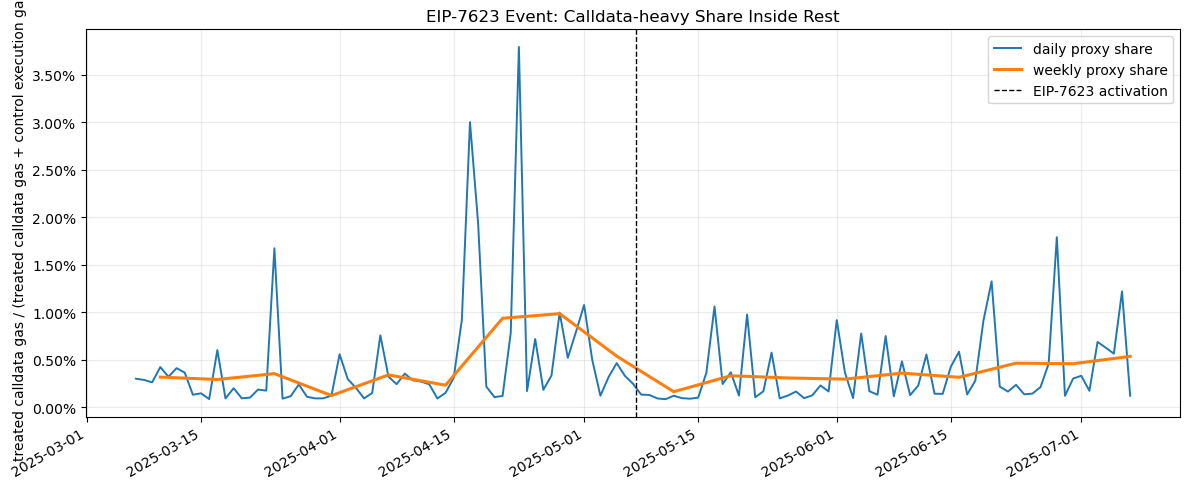

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily["date"], daily["data_share_rest_gas_proxy"], label="daily proxy share", linewidth=1.4)
ax.plot(weekly["date"], weekly["data_share_rest_gas_proxy"], label="weekly proxy share", linewidth=2.2)
ax.axvline(pd.Timestamp(ACTIVATION_TS), color="black", linestyle="--", linewidth=1, label="EIP-7623 activation")
ax.set_title("EIP-7623 Event: Calldata-heavy Share Inside Rest")
ax.set_ylabel("treated calldata gas / (treated calldata gas + control execution gas)")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(alpha=0.25)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(SHARE_PLOT, dpi=160)
SHARE_PLOT

PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/eip7623_event_treated_activity_2025-03-07_2025-07-08.png')

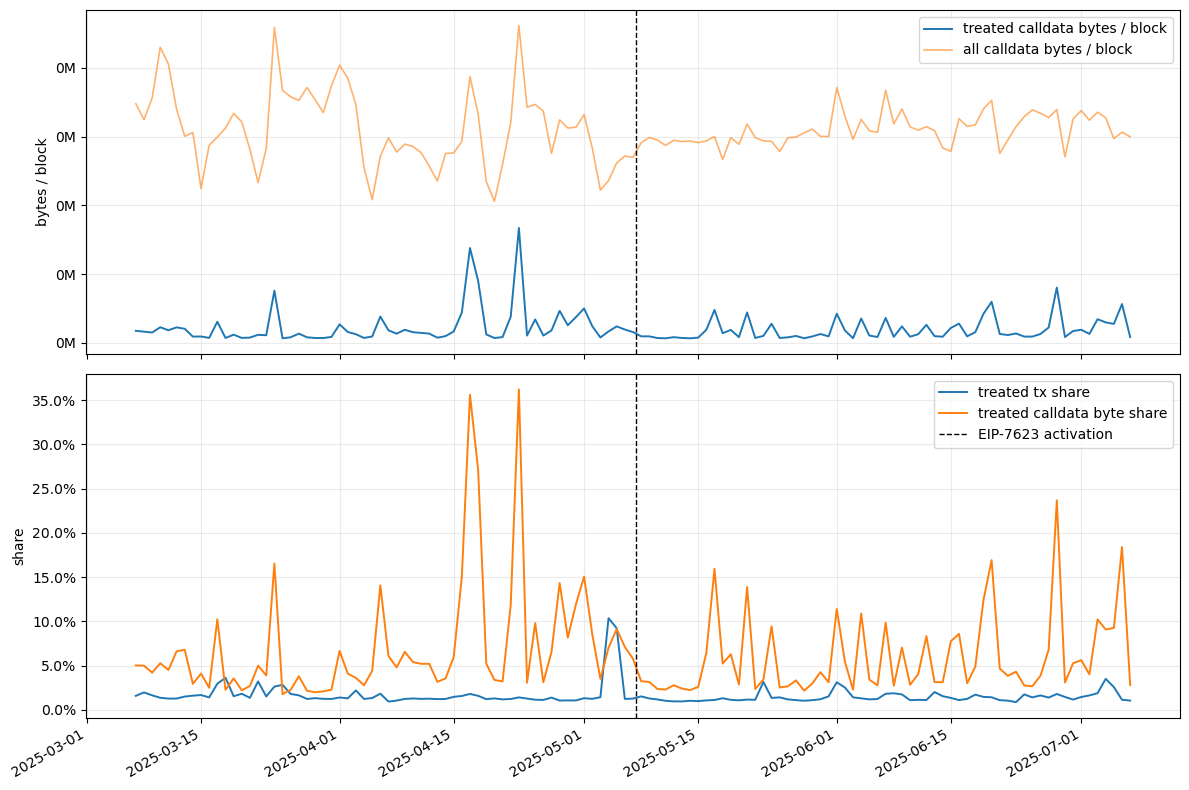

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(daily["date"], daily["treated_calldata_bytes_per_block"], label="treated calldata bytes / block", linewidth=1.4)
axes[0].plot(daily["date"], daily["calldata_bytes_per_block"], label="all calldata bytes / block", linewidth=1.2, alpha=0.6)
axes[0].axvline(pd.Timestamp(ACTIVATION_TS), color="black", linestyle="--", linewidth=1)
axes[0].set_ylabel("bytes / block")
axes[0].yaxis.set_major_formatter(FuncFormatter(millions))
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(daily["date"], daily["treated_tx_share"], label="treated tx share", linewidth=1.4)
axes[1].plot(daily["date"], daily["treated_calldata_byte_share"], label="treated calldata byte share", linewidth=1.4)
axes[1].axvline(pd.Timestamp(ACTIVATION_TS), color="black", linestyle="--", linewidth=1, label="EIP-7623 activation")
axes[1].set_ylabel("share")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(TREATED_PLOT, dpi=160)
TREATED_PLOT

## Recover Implied Data And Execution Elasticities

The EIP-7623 event gives an estimate of `eta_data`, the data-vs-execution
substitution/share elasticity inside the non-state `rest` bucket. By itself,
`eta_data` is not an own-price elasticity.

To recover implied calldata/data and execution elasticities, use the nested-share
approximation:

```text
epsilon_data ~= epsilon_rest + eta_data * (1 - alpha_data_given_rest)

epsilon_execution ~= epsilon_rest - eta_data * alpha_data_given_rest
```

where:

```text
alpha_data_given_rest = data / (data + execution)
```

The important accounting detail is that `execution` should be state-cleaned. This
notebook computes:

```text
data = all standard calldata gas
execution_state_cleaned = all non-calldata body gas - current-rule state-creation gas
alpha_data_given_rest_state_cleaned =
    data / (data + execution_state_cleaned)
```

The sweep below uses the **pre-fork state-cleaned alpha** by default, because it
is the baseline resource share before the EIP-7623 price shock.

Interpretation:

- `epsilon_rest` comes from Maria/state-vs-rest calibration.
- `alpha_data_given_rest` comes from the state-cleaned historical resource decomposition.
- `eta_data` comes from this EIP-7623 calldata event study or from a sweep.

The guardrail is:

```text
epsilon_execution >= 0
eta_data <= epsilon_rest / alpha_data_given_rest
```

This is an approximation for simulator calibration, not a claim that EIP-7623
identifies the full structural 7999 data elasticity. EIP-7623 shocks calldata;
full 7999 data also includes access-list bytes, authorization tuples, blob
hashes, and BAL bytes.

In [21]:
EPSILON_REST = 0.08
ETA_DATA_SWEEP = [0.0, 0.1, 0.3, 0.43, 0.6, 1.0]

# Compute alpha_data|rest from the same state-cleaned accounting used above.
# Data is all standard calldata gas, not only the treated/floor-bound subset.
daily["execution_body_gas_state_cleaned_all"] = (
    daily["execution_body_gas_proxy"]
    - daily["historical_state_creation_gas"]
).clip(lower=0)
daily["alpha_data_given_rest_uncleaned_daily"] = daily["standard_calldata_gas"] / (
    daily["standard_calldata_gas"] + daily["execution_body_gas_proxy"]
).replace(0, np.nan)
daily["alpha_data_given_rest_state_cleaned_daily"] = daily["standard_calldata_gas"] / (
    daily["standard_calldata_gas"] + daily["execution_body_gas_state_cleaned_all"]
).replace(0, np.nan)


def alpha_data_given_rest(frame: pd.DataFrame, *, state_cleaned: bool) -> dict:
    data = float(frame["standard_calldata_gas"].sum())
    execution_col = (
        "execution_body_gas_state_cleaned_all"
        if state_cleaned
        else "execution_body_gas_proxy"
    )
    execution = float(frame[execution_col].sum())
    return {
        "data_gas": data,
        "execution_gas": execution,
        "alpha_data_given_rest": data / (data + execution) if (data + execution) > 0 else np.nan,
    }

alpha_pre = daily[(daily["date"] >= pre_start) & (daily["date"] < pre_end)].copy()
alpha_post = daily[(daily["date"] >= post_start) & (daily["date"] <= post_end)].copy()
alpha_full = daily[daily["phase"] != "activation_day"].copy()

alpha_rows = []
for label, frame in [
    ("pre", alpha_pre),
    ("post", alpha_post),
    ("full_excluding_activation_day", alpha_full),
]:
    for state_cleaned in [False, True]:
        row = alpha_data_given_rest(frame, state_cleaned=state_cleaned)
        row.update(
            {
                "period": label,
                "state_cleaned": state_cleaned,
                "days": len(frame),
                "block_count": int(frame["block_count"].sum()),
            }
        )
        alpha_rows.append(row)

alpha_summary = pd.DataFrame(alpha_rows)[
    [
        "period",
        "state_cleaned",
        "days",
        "block_count",
        "data_gas",
        "execution_gas",
        "alpha_data_given_rest",
    ]
]
if WRITE_CSV:
    alpha_summary.to_csv(ALPHA_SHARE_CSV, index=False)
    daily.to_csv(DAILY_CSV, index=False)
    print("wrote", ALPHA_SHARE_CSV)
    print("wrote", DAILY_CSV)

ALPHA_DATA_GIVEN_REST = float(
    alpha_summary.loc[
        (alpha_summary["period"] == "pre")
        & (alpha_summary["state_cleaned"]),
        "alpha_data_given_rest",
    ].iloc[0]
)
ALPHA_DATA_GIVEN_REST_SOURCE = "pre_fork_state_cleaned_standard_calldata_share"

state_clean_eta = float(state_clean_summary.loc[0, "eta_effective_receipt_body_state_cleaned"])
main_eta = float(summary.loc[0, "eta_data_effective_receipt_body"])


def recover_data_execution_elasticities(
    epsilon_rest: float,
    alpha_data_given_rest: float,
    eta_data: float,
) -> dict:
    epsilon_data = epsilon_rest + eta_data * (1.0 - alpha_data_given_rest)
    epsilon_execution = epsilon_rest - eta_data * alpha_data_given_rest
    eta_upper_bound = epsilon_rest / alpha_data_given_rest if alpha_data_given_rest > 0 else np.inf
    return {
        "epsilon_rest": epsilon_rest,
        "alpha_data_given_rest": alpha_data_given_rest,
        "alpha_data_given_rest_source": ALPHA_DATA_GIVEN_REST_SOURCE,
        "eta_data": eta_data,
        "epsilon_data": epsilon_data,
        "epsilon_execution": epsilon_execution,
        "eta_upper_bound_for_nonnegative_execution": eta_upper_bound,
        "valid_nonnegative_execution": epsilon_execution >= 0,
    }

sweep_rows = []
for eta in ETA_DATA_SWEEP:
    row = recover_data_execution_elasticities(
        EPSILON_REST,
        ALPHA_DATA_GIVEN_REST,
        eta,
    )
    if np.isclose(eta, 0.0):
        row["interpretation"] = "fixed data/execution split"
    elif np.isclose(eta, 0.43):
        row["interpretation"] = "state-cleaned EIP-7623 central prior"
    elif eta >= 1.0:
        row["interpretation"] = "aggressive short-run sensitivity"
    else:
        row["interpretation"] = "sensitivity"
    sweep_rows.append(row)

# Include the exact notebook estimates as labelled reference rows too.
for label, eta in [
    ("main long-window effective eta", main_eta),
    ("state-cleaned long-window effective eta", state_clean_eta),
]:
    row = recover_data_execution_elasticities(
        EPSILON_REST,
        ALPHA_DATA_GIVEN_REST,
        eta,
    )
    row["interpretation"] = label
    sweep_rows.append(row)

elasticity_sweep = pd.DataFrame(sweep_rows)
if WRITE_CSV:
    elasticity_sweep.to_csv(ELASTICITY_SWEEP_CSV, index=False)
    print("wrote", ELASTICITY_SWEEP_CSV)

display(alpha_summary)
elasticity_sweep[
    [
        "eta_data",
        "epsilon_rest",
        "alpha_data_given_rest",
        "epsilon_data",
        "epsilon_execution",
        "valid_nonnegative_execution",
        "interpretation",
    ]
]

wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_alpha_data_given_rest_2025-03-07_2025-07-08.csv
wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_daily_2025-03-07_2025-07-08.csv
wrote /Users/william/PycharmProjects/eip-7999-research/data/eip7623_event_implied_elasticity_sweep_2025-03-07_2025-07-08.csv


,period,state_cleaned,days,block_count,data_gas,execution_gas,alpha_data_given_rest
0,pre,False,60,429414,"240,324,050,032.0000","6,078,314,755,784.0000",0.0380
1,pre,True,60,429414,"240,324,050,032.0000","4,337,836,281,784.0000",0.0525
2,post,False,60,428225,"221,080,758,296.0000","5,819,493,453,498.0000",0.0366
3,post,True,60,428225,"221,080,758,296.0000","4,491,934,114,898.0000",0.0469
4,full_excluding_activation_day,False,122,871844,"468,147,858,880.0000","12,093,170,310,459.0000",0.0373
5,full_excluding_activation_day,True,122,871844,"468,147,858,880.0000","8,976,625,467,659.0000",0.0496


,eta_data,epsilon_rest,alpha_data_given_rest,epsilon_data,epsilon_execution,valid_nonnegative_execution,interpretation
0,0.0000,0.0800,0.0525,0.0800,0.0800,True,fixed data/execution split
1,0.1000,0.0800,0.0525,0.1748,0.0748,True,sensitivity
2,0.3000,0.0800,0.0525,0.3643,0.0643,True,sensitivity
3,0.4300,0.0800,0.0525,0.4874,0.0574,True,state-cleaned EIP-7623 central prior
4,0.6000,0.0800,0.0525,0.6485,0.0485,True,sensitivity
5,1.0000,0.0800,0.0525,1.0275,0.0275,True,aggressive short-run sensitivity
6,0.3262,0.0800,0.0525,0.3891,0.0629,True,main long-window effective eta
7,0.4294,0.0800,0.0525,0.4869,0.0575,True,state-cleaned long-window effective eta


## How To Read This

- If receipt-gas coverage is high, Xatu is enough for this first-pass calldata
  event study.
- The main estimate is a **surviving-floor-bound calldata-share response**, not
  the full calldata demand elasticity and not the full 7999 data-resource
  elasticity.
- Prefer the effective price-ratio estimate for simulator sweeps; keep the `2.5x`
  estimate as the clean theoretical benchmark.
- The output should seed sensitivity ranges for `eta_data`, not become a single
  fixed parameter.
- Blob controls and composition-stable high-calldata-intensity cohorts are the
  next improvements if this event study becomes a central empirical input.
